In [1]:
import numpy as np
import scipy.io
import scipy.signal
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def load_emg_data(file_path, file_name):
    mat = scipy.io.loadmat(file_path)  
    data_struct = mat[file_name][0, 0]  
    analog_data = data_struct['Analog'][0, 0]
    analog_data_values = analog_data['Data']
    emg_data = analog_data_values[:5, :40000].T 
    return emg_data

stoop_80 = load_emg_data('./SUB1/aux_static_stoop_80_2.mat', 'aux_static_stoop_80_2')
mvc = load_emg_data('./SUB1/mvc.mat', 'mvc')

In [3]:
def process_emg_data(emg_data, fs, low_cutoff=30, high_cutoff=300, envelope_cutoff=6):
    nyquist = 0.5 * fs
    low = low_cutoff / nyquist
    high = high_cutoff / nyquist
    sos = scipy.signal.butter(2, [low, high], btype='band', output='sos')

    filtered_emg_data = scipy.signal.sosfiltfilt(sos, emg_data, axis=0)
    rectified_emg_data = np.abs(filtered_emg_data)

    low_pass = envelope_cutoff / nyquist
    sos_low_pass = scipy.signal.butter(2, low_pass, btype='low', output='sos')

    envelope_emg_data = scipy.signal.sosfiltfilt(sos_low_pass, rectified_emg_data, axis=0)

    return filtered_emg_data, envelope_emg_data


[0.07643457 0.09277876 0.07714004 0.11246151 0.1023069 ]


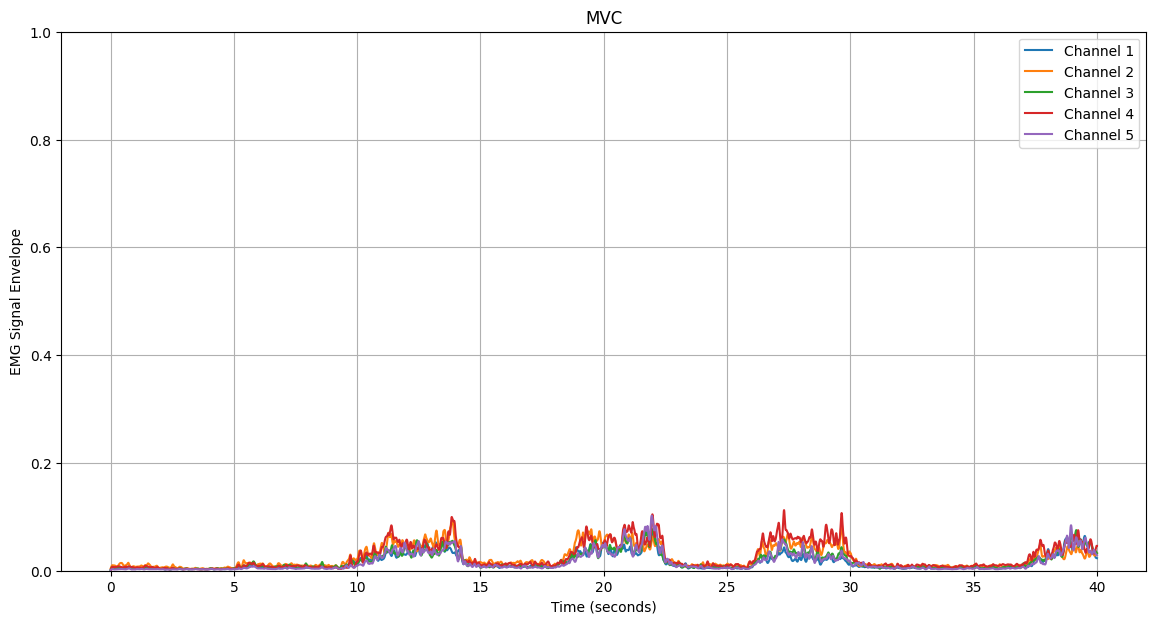

In [4]:
fs = 1000
_, mvc_emg = process_emg_data(mvc, fs=1000)

max_mvc = np.max(mvc_emg, axis=0)
print(max_mvc)


time = np.arange(mvc_emg.shape[0]) / fs
plt.figure(figsize=(14, 7))
for i in range(mvc_emg.shape[1]):
    plt.plot(time, mvc_emg[:, i], label=f'Channel {i+1}')

plt.title('MVC')
plt.xlabel('Time (seconds)')
plt.ylabel('EMG Signal Envelope')
plt.ylim(0, 1)
#plt.xlim(15, 20)
plt.legend()
plt.grid(True)
plt.show()

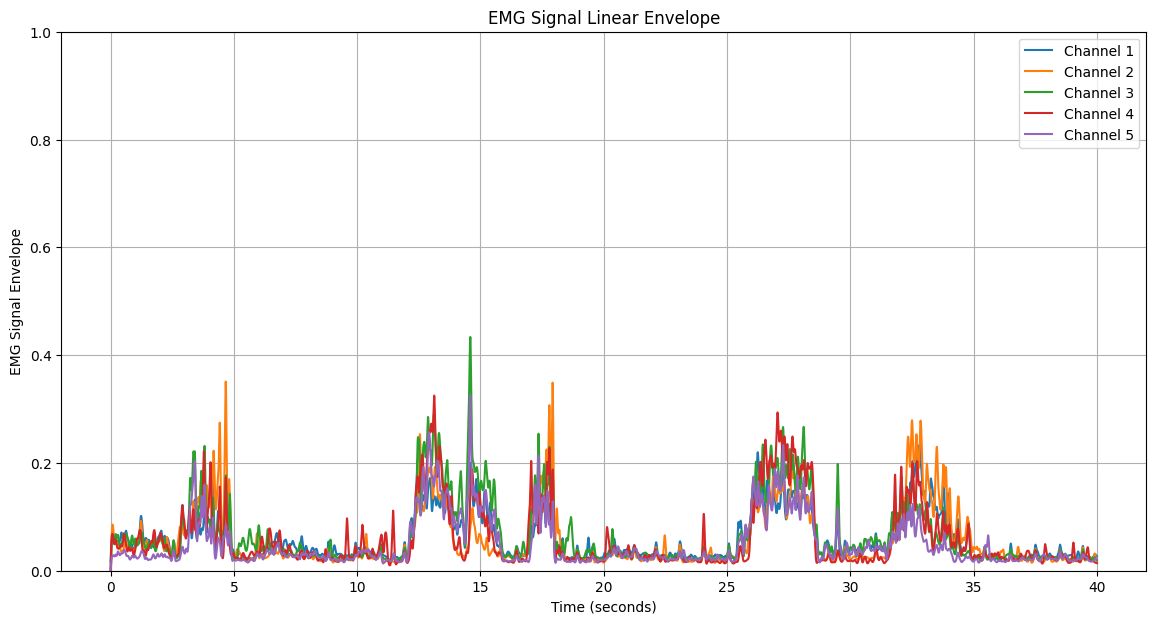

In [5]:
# Plotting the filtered (envelope) data
fs = 1000
_, stoop_80_emg = process_emg_data(stoop_80, fs=1000)

stoop_80_emg = stoop_80_emg / max_mvc


time = np.arange(stoop_80_emg.shape[0]) / fs
plt.figure(figsize=(14, 7))
for i in range(stoop_80_emg.shape[1]):
    plt.plot(time, stoop_80_emg[:, i], label=f'Channel {i+1}')

plt.title('EMG Signal Linear Envelope')
plt.xlabel('Time (seconds)')
plt.ylabel('EMG Signal Envelope')
plt.ylim(0, 1)
#plt.xlim(15, 20)
plt.legend()
plt.grid(True)
plt.show()

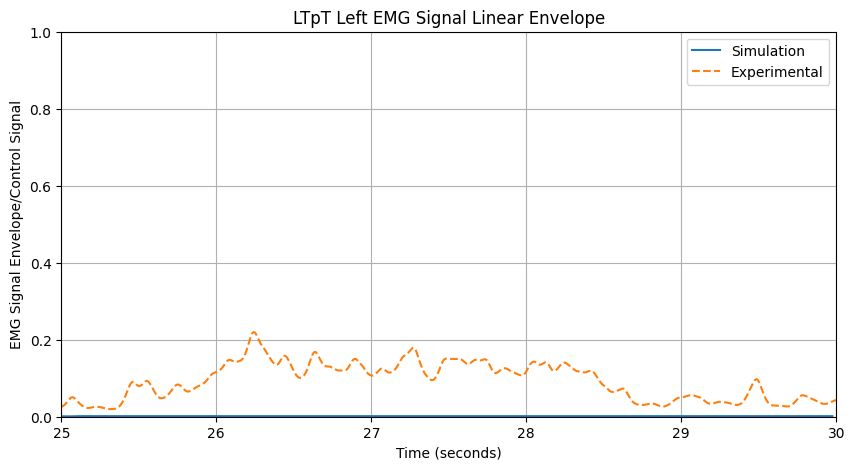

In [ ]:
#get exo80 _9  
df=[0.8276441334100086,0.8728326302799254,0.8610105840466103,0.8284725718288967,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283,0.7806120731883283]
plt.figure(figsize=(10, 5))
#for i in range(stoop_80_emg.s
#for i in range(stoop_80_emg.shape[1]):
#    plt.plot(time, stoop_80_emg[:, i], label=f'Channel {i+1}')

plt.title('LTpL Right EMG Signal Linear Envelope')
plt.xlabel('Time (seconds)')
plt.ylabel('EMG Signal Envelope/Control Signal')
x2 = np.arange(200)
x2_in_seconds = (x2*0.025)+25
plt.plot(x2_in_seconds,df,linestyle = '-',label="Simulation")
plt.plot(time,stoop_80_emg[:,2],linestyle='--',label="Experimental")
plt.ylim(0, 1)
plt.xlim(25, 30)
plt.legend()
plt.grid(True)
plt.show()